# Financial Sentiment Analysis and Stock Return Prediction

1. This notebook investigates the relationship between news sentiment and stock price movements across 10 major stocks from 2020–2024. Using 48,000+ financial news articles scored with TextBlob, VADER, and FinBERT.
2. Building and evaluating predictive models to assess whether sentiment carries actionable signal.

- **Stocks:** AMD, BRK, CVX, DIS, GOOG, GS, INTC, NVDA, WMT, XOM
- **Time Period:** 2020–2024
- **Methods:** Correlation analysis, OLS Regression, Logistic Regression, Random Forest
- **Sentiment Models:** TextBlob (lexicon), VADER (lexicon, finance-optimised), FinBERT (BERT fine-tuned on financial text)

# 1. Setup

In [56]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('Successfully loaded libraries')

Successfully loaded libraries


In [57]:
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1.2 Loading Data

In [58]:
data_path = Path("../data/merged_stock_news_prices_2019_2024.csv")

if not data_path.exists():
    
    import urllib.request
    print("Downloading dataset from Hugging Face: ")

    data_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://huggingface.co/datasets/karthikkolli17/financial-news-sentiment/resolve/main/merged_stock_news_prices_2019_2024.csv",
        data_path
    )

    print("Completed downloading.")

In [59]:
df = pd.read_csv(data_path)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 50,153 rows x 19 columns


## 2. Data Cleaning 

In [60]:
# Dropping columns with missing values

df = df.drop(columns=['Author', 'Publisher', 'Article'])

In [61]:
# Removing duplicates

org = len(df)
df = df.drop_duplicates()
print(f"Removed {org - len(df):,} duplicates")

Removed 1,579 duplicates


In [62]:
# Converting date and sorting

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Stock_symbol', 'Date']).reset_index(drop=True)

In [63]:
# Compute next day return at daily level

daily = df.groupby(['Stock_symbol', 'Date'])['Close'].last().reset_index()
daily = daily.sort_values(['Stock_symbol', 'Date'])
daily['next_close'] = daily.groupby('Stock_symbol')['Close'].shift(-1)
daily['price_change'] = daily['next_close'] - daily['Close']
daily['price_change_percent'] = (daily['price_change']/daily['Close']) * 100
daily['price_up'] = (daily['price_change'] > 0).astype(int)
daily = daily.dropna(subset=['next_close'])

# Merging back to articles
df = df.merge(
    daily[['Stock_symbol', 'Date', 'next_close', 'price_change', 'price_change_percent', 'price_up']],
    on = ['Stock_symbol', 'Date'],
    how = 'inner'
)

print(f"Final dataset: {len(df):,} rows")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Price direction: {df['price_up'].mean()*100:.1f}% up days")

Final dataset: 48,515 rows
Date range: 2020-11-27 to 2024-01-08
Price direction: 51.1% up days


## 3. Sentiment Analysis

In [64]:
%pip install textblob vaderSentiment transformers torch tqdm -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [65]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import torch
from transformers import pipeline
from tqdm.auto import tqdm
import nltk
nltk.download('punkt', quiet=True)

vader = SentimentIntensityAnalyzer()
print('Libraries for Sentiment Analysis loaded.')

Libraries for Sentiment Analysis loaded.


In [66]:
# scoring each article using Textblob: polarity + subjectivity and VADER: compound + pos/neu/neg
# Textblob uses Lexicon-based approach. VADER is optimised for short, informal financial text
# In here, using Textrank_summary as it provides a concise, noise-reduced version of each article

def score(text):

    text = str(text)
    tb = TextBlob(text)
    vs = vader.polarity_scores(text)

    return {
        'tb_polarity': tb.sentiment.polarity, # -1 to +1
        'tb_subjectivity': tb.sentiment.subjectivity, # 0 to +1
        'vader_compound': vs['compound'], # -1 to +1
        'vader_positive': vs['pos'], # 0 to +1
        'vader_neutral': vs['neu'], # 0 to +1
        'vader_negative': vs['neg'], # 0 to +1
    }

print("Scoring articles: ")
scores = df['Textrank_summary'].apply(lambda x: pd.Series(score(x)))
df = pd.concat([df, scores], axis = 1)
print(f"Scored {len(df):,} articles")
print(df[['tb_polarity', 'tb_subjectivity', 'vader_compound']].describe())

Scoring articles: 
Scored 48,515 articles
       tb_polarity  tb_subjectivity  vader_compound
count   48515.0000       48515.0000      48515.0000
mean        0.1247           0.4626          0.5210
std         0.1536           0.1522          0.4804
min        -0.8500           0.0000         -0.9909
25%         0.0222           0.3627          0.3182
50%         0.1120           0.4557          0.7096
75%         0.2167           0.5625          0.8860
max         1.0000           1.0000          0.9982


In [67]:
# ProsusAI/finbert: BERT fine tuned specifically on financial text

device = 0 if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else -1)
                                                                                                                                                                                                                                    
finbert = pipeline(                                                                                                                                                                                                               
    "text-classification",                                                                                                                                                                                                        
    model = "ProsusAI/finbert",                                                                                                                                                                                                     
    tokenizer = "ProsusAI/finbert",                                                                                                                                                                                                 
    top_k = None,                  
    device = device
)

print(f"FinBERT loaded on: {'GPU' if torch.cuda.is_available() else 'MPS' if torch.backends.mps.is_available() else 'CPU'}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 46258.17it/s]


FinBERT loaded on: MPS


In [68]:
# Cache avoids re-running 25-min FinBERT inference on every kernel restart
CACHE = Path("../data/finbert_scores.csv")

if CACHE.exists():
    fb_df = pd.read_csv(CACHE)
    print(f"Loaded FinBERT scores from cache: {len(fb_df):,} rows")
else:
    print("Scoring with FinBERT (first run — saves cache for future runs)...")
    texts = [str(t)[:512] for t in df['Textrank_summary'].tolist()]
    preds = finbert(texts, truncation=True, max_length=128, batch_size=64)
    fb_df = pd.DataFrame([{
        'finbert_positive': next(p['score'] for p in pred if p['label'] == 'positive'),
        'finbert_negative': next(p['score'] for p in pred if p['label'] == 'negative'),
        'finbert_neutral':  next(p['score'] for p in pred if p['label'] == 'neutral'),
    } for pred in preds])
    fb_df['finbert_compound'] = fb_df['finbert_positive'] - fb_df['finbert_negative']
    fb_df.to_csv(CACHE, index=False)
    print("Done and cached.")

df = pd.concat([df.reset_index(drop=True), fb_df], axis=1)
print(f"{len(df):,} articles with FinBERT scores.")
print(df[['finbert_compound', 'finbert_positive', 'finbert_negative']].describe())

Loaded FinBERT scores from cache: 48,515 rows
48,515 articles with FinBERT scores.
       finbert_compound  finbert_positive  finbert_negative
count        48515.0000        48515.0000        48515.0000
mean             0.0369            0.3102            0.2733
std              0.6193            0.3500            0.3764
min             -0.9701            0.0059            0.0062
25%             -0.4128            0.0326            0.0156
50%              0.0480            0.1088            0.0341
75%              0.5704            0.6450            0.5765
max              0.9448            0.9625            0.9780


## 4. EDA - Exploratory Data Analysis

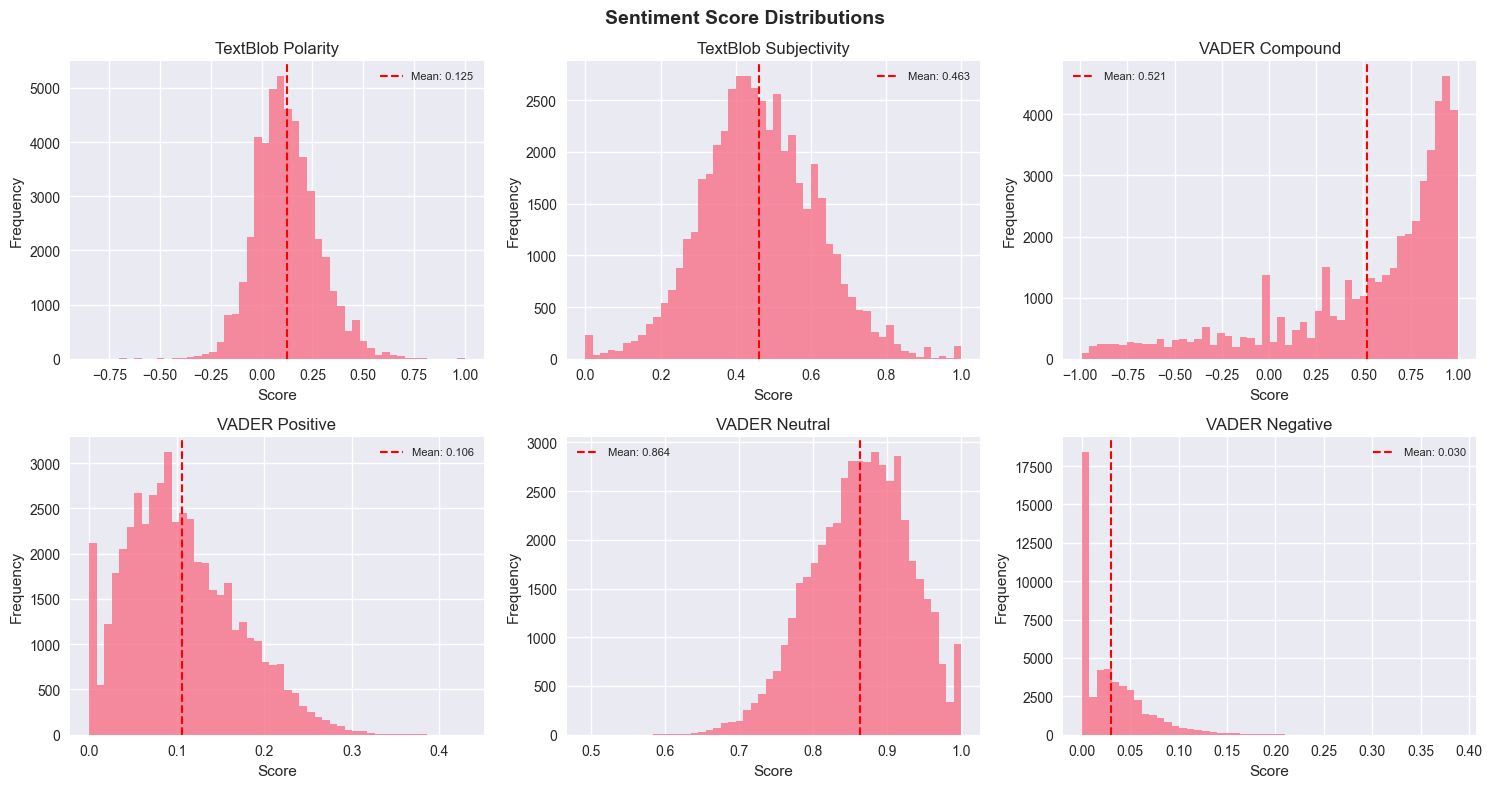

In [69]:
# VADER skews positive for financial news
# TextBlob subjectivity tells us how opinion-based vs fact-based the coverage is

fig, axes = plt.subplots(2, 3, figsize = (15, 8))
fig.suptitle('Sentiment Score Distributions', fontsize = 14, fontweight = 'bold')

cols = ['tb_polarity', 'tb_subjectivity', 'vader_compound', 'vader_positive', 'vader_neutral', 'vader_negative']
titles = ['TextBlob Polarity', 'TextBlob Subjectivity', 'VADER Compound', 'VADER Positive', 'VADER Neutral', 'VADER Negative']

for ax, col, title in zip(axes.flatten(), cols, titles):

    ax.hist(df[col], bins = 50, edgecolor = 'none', alpha = 0.8)
    ax.axvline(df[col].mean(), color = 'red', linestyle = '--', linewidth = 1.5, label = f"Mean: {df[col].mean():.3f}")
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize = 8)

plt.tight_layout()
plt.show()

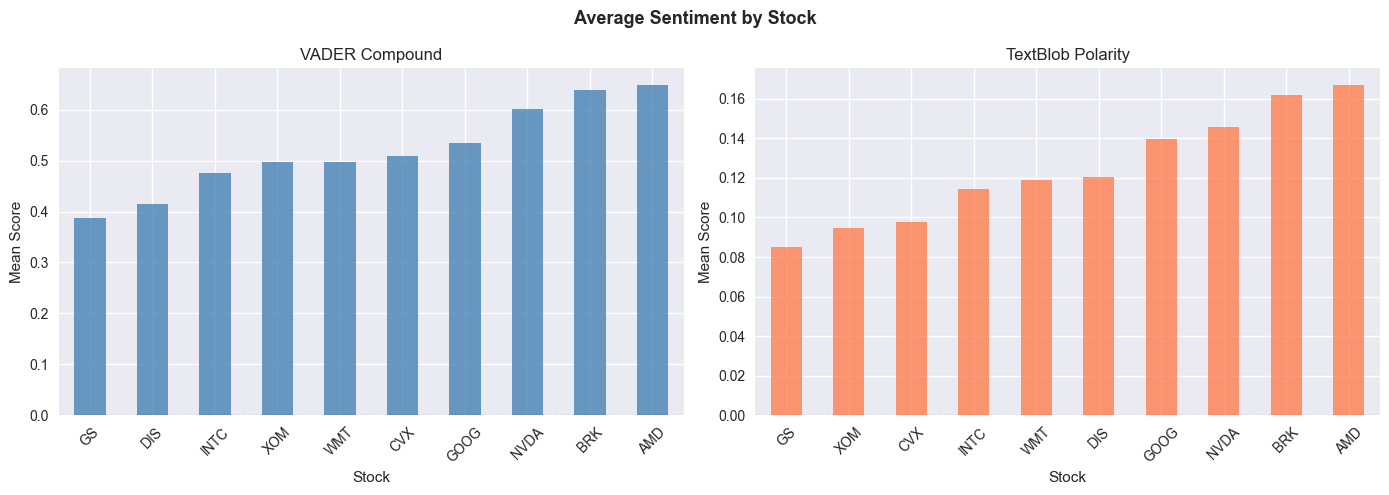

In [70]:
# Average Sentiment per stock. Reveals which stocks receive more positive/negative coverage
# Helps contextualising later

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle('Average Sentiment by Stock', fontsize = 13, fontweight = 'bold')

vader_per_stock = df.groupby('Stock_symbol')['vader_compound'].mean().sort_values()
tb_per_stock = df.groupby('Stock_symbol')['tb_polarity'].mean().sort_values()

vader_per_stock.plot(kind = 'bar', ax = axes[0], color = 'steelblue', alpha = 0.8)
axes[0].set_title('VADER Compound')                                                                                                                                                                                               
axes[0].set_xlabel('Stock')                                                                                                                                                                                                       
axes[0].set_ylabel('Mean Score')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')                                                                                                                                                                  
axes[0].tick_params(axis='x', rotation=45)

tb_per_stock.plot(kind = 'bar', ax = axes[1], color = 'coral', alpha = 0.8)
axes[1].set_title('TextBlob Polarity')                                                                                                                                                                                            
axes[1].set_xlabel('Stock')
axes[1].set_ylabel('Mean Score')                                                                                                                                                                                                  
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

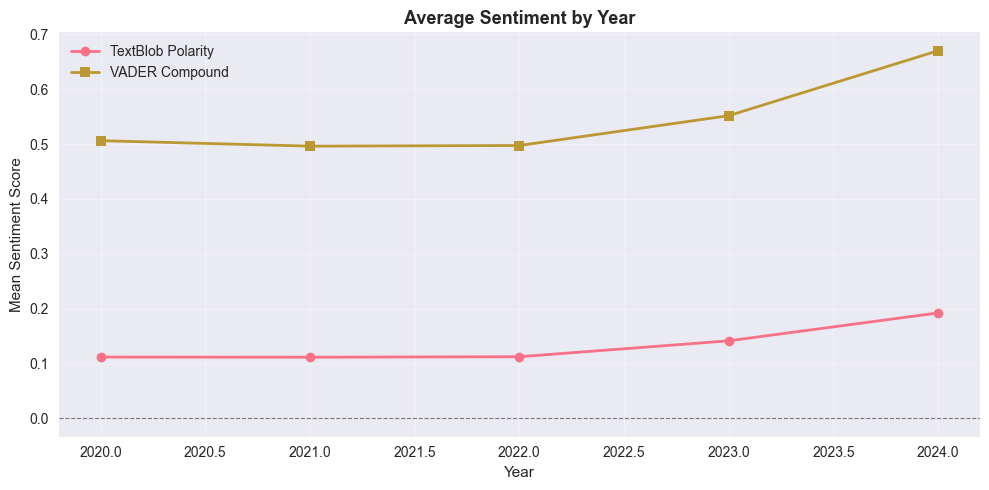

In [71]:
# Sentiment trends by year - shift post COVID, rate hikes, etc.
# Declining or shifting sentiment over time can explain correlations

yearly = df.groupby(df['Date'].dt.year)[['tb_polarity', 'vader_compound']].mean()

fig, ax = plt.subplots(figsize=(10, 5))                                                                                                                                                                                           
ax.plot(yearly.index, yearly['tb_polarity'], marker='o', label='TextBlob Polarity', linewidth=2)
ax.plot(yearly.index, yearly['vader_compound'], marker='s', label='VADER Compound', linewidth=2)                                                                                                                                  
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Average Sentiment by Year', fontsize=13, fontweight='bold')                                                                                                                                                         
ax.set_xlabel('Year')
ax.set_ylabel('Mean Sentiment Score')                                                                                                                                                                                             
ax.legend()     
ax.grid(True, alpha=0.3)                                                                                                                                                                                                          
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

In [72]:
# Pearson + Spearman correlation between each sentiment feature and next day price change
# Pearson measures linear relationship. Spearman is rank based and handles non linearity
# Both p-values reported, with 48k rows, even tiny correlations can be statistically significant
# finbert_neutral excluded — it equals 1 - positive - negative (perfectly collinear)

sentiment_cols = [
    'tb_polarity', 'tb_subjectivity',
    'vader_compound', 'vader_positive', 'vader_neutral', 'vader_negative',
    'finbert_compound', 'finbert_positive', 'finbert_negative'
]

results = []
for col in sentiment_cols:

    r, pr = stats.pearsonr(df[col], df['price_change_percent'])
    rho, prho = stats.spearmanr(df[col], df['price_change_percent'])

    results.append({
        'Feature': col,
        'Pearson_r': round(r, 4),
        'Pearson_p': round(pr, 4),
        'Spearman_rho': round(rho, 4),
        'Spearman_p': round(prho, 4),
        'Significant': 'Yes' if pr < 0.05 else 'No'
    })

corr_df = pd.DataFrame(results)
print(corr_df.to_string(index=False))

         Feature  Pearson_r  Pearson_p  Spearman_rho  Spearman_p Significant
     tb_polarity     0.0042     0.3607        0.0025      0.5874          No
 tb_subjectivity     0.0017     0.7018       -0.0013      0.7816          No
  vader_compound    -0.0097     0.0323       -0.0024      0.6042         Yes
  vader_positive    -0.0022     0.6248       -0.0056      0.2158          No
   vader_neutral    -0.0002     0.9618        0.0025      0.5853          No
  vader_negative     0.0045     0.3167       -0.0007      0.8819          No
finbert_compound    -0.0076     0.0937       -0.0057      0.2109          No
finbert_positive    -0.0089     0.0493       -0.0034      0.4597         Yes
finbert_negative     0.0042     0.3525        0.0019      0.6824          No


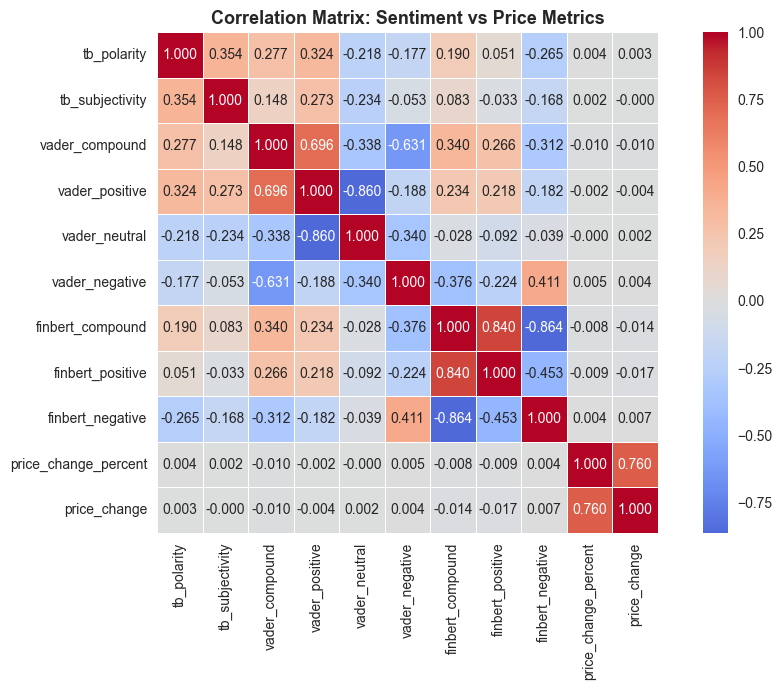

In [73]:
# Heatmap showing correlations between all sentiment features and price metrics
# Visualises and spotting patterns all across features

corr_matrix = df[sentiment_cols + ['price_change_percent', 'price_change']].corr()

plt.figure(figsize = (10, 7))
sns.heatmap(corr_matrix, annot = True, fmt = '.3f', cmap = 'coolwarm', center = 0, square = True, linewidths = 0.5)
plt.title('Correlation Matrix: Sentiment vs Price Metrics', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [74]:
# Lag analysis
# does sentiment today predict returns tomorrow, 2 days, or 3 days out?
# If correlations strengthen at lag 1-2, sentiment has delayed predictive power
# aggregate to daily level to avoid duplicate article bias

daily_sentiment = df.groupby('Date')[['tb_polarity', 'vader_compound', 'price_change_percent']].mean().reset_index()                                                                                                              
daily_sentiment = daily_sentiment.sort_values('Date')
                                                                                                                                                                                                                                    
print(f"{'Lag':<6} {'VADER r':>10} {'VADER p':>10} {'TextBlob r':>12} {'TextBlob p':>12}")                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

for lag in range(0, 4):
    shifted = daily_sentiment['price_change_percent'].shift(-lag)                                                                                                                                                                 
    valid = daily_sentiment[shifted.notna()]
    r_v, p_v = stats.pearsonr(valid['vader_compound'], shifted[shifted.notna()])
    r_t, p_t = stats.pearsonr(valid['tb_polarity'],    shifted[shifted.notna()])
    print(f"{lag:<6} {r_v:>10.4f} {p_v:>10.4f} {r_t:>12.4f} {p_t:>12.4f}")

Lag       VADER r    VADER p   TextBlob r   TextBlob p
0         -0.0393     0.2723       0.0290       0.4183
1         -0.0104     0.7710       0.0326       0.3636
2         -0.0386     0.2811       0.0244       0.4960
3         -0.0758     0.0344       0.0289       0.4201


## 6. Predictive Modeling

1. Correlations tell us *if* a relationship exists. 
2. Models tell us *how useful* that relationship is for prediction. 
3. Testing three approaches.

In [75]:
%pip install scikit-learn statsmodels xgboost -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [76]:
# import libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

print('Successfully loaded modelling libraries.')

Successfully loaded modelling libraries.


In [77]:
# Features and target
# Using all 6 sentiment scores as features, price_up (1=up, 0=down) as the binary target                                                                                                                                          
# 80/20 train/test split — stratified to preserve class balance across both sets                                                                                                                                                  
                                                                                                                                                                                                                                    
features = ['tb_polarity', 'tb_subjectivity', 'vader_compound', 'vader_positive', 'vader_neutral', 'vader_negative', 'finbert_compound', 'finbert_positive', 'finbert_negative', 'finbert_neutral']                                                                                                                                                                  
                                                                                                                                                                                                                                    
X = df[features]
Y = df['price_up']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

In [78]:
# Scaling Features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} rows and Test: {X_test.shape[0]:,} rows")
print(f"Class balance: Train: {Y_train.mean()*100:.1f}% up and Test: {Y_test.mean()*100:.1f}% up")

Train: 38,812 rows and Test: 9,703 rows
Class balance: Train: 51.1% up and Test: 51.1% up


In [79]:
# Model 1: OLS Regression

X_ols = sm.add_constant(X_train)  # adds intercept                                                                                                                                                                                
ols_model = sm.OLS(df.loc[X_train.index, 'price_change_percent'], X_ols).fit()                                                                                                                                                    
print(ols_model.summary())

                             OLS Regression Results                             
Dep. Variable:     price_change_percent   R-squared:                       0.000
Model:                              OLS   Adj. R-squared:                 -0.000
Method:                   Least Squares   F-statistic:                    0.7796
Date:                  Sat, 25 Apr 2026   Prob (F-statistic):              0.635
Time:                          19:40:42   Log-Likelihood:                -90524.
No. Observations:                 38812   AIC:                         1.811e+05
Df Residuals:                     38802   BIC:                         1.812e+05
Df Model:                             9                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.

In [80]:
# Model 2: Logistic Regression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, Y_train)                                                                                                                                                                                                       
Y_pred_lr = lr.predict(X_test_sc)
Y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
                                                                                                                                         
print(f"Logistic Regression Accuracy: {accuracy_score(Y_test, Y_pred_lr)*100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(Y_test, Y_prob_lr):.4f}")                                                                                                                                                   
print("\nClassification Report:")                                                                                                                                                                                                 
print(classification_report(Y_test, Y_pred_lr, target_names=["Down", "Up"]))

Logistic Regression Accuracy: 51.20%
ROC-AUC: 0.5164

Classification Report:
              precision    recall  f1-score   support

        Down       0.50      0.20      0.29      4747
          Up       0.51      0.81      0.63      4956

    accuracy                           0.51      9703
   macro avg       0.51      0.51      0.46      9703
weighted avg       0.51      0.51      0.46      9703



In [81]:
# Model 3: Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)                                                                                                                                                         
rf.fit(X_train_sc, Y_train)
Y_pred_rf = rf.predict(X_test_sc)                                                                                                                                                                                                 
Y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]
                                                                                                                                                                                                                                    
print(f"Random Forest Accuracy: {accuracy_score(Y_test, Y_pred_rf)*100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(Y_test, Y_prob_rf):.4f}")                                                                                                                                                          
print("\nClassification Report:")                                                                                                                                                                                                 
print(classification_report(Y_test, Y_pred_rf, target_names=["Down", "Up"]))


Random Forest Accuracy: 53.84%
ROC-AUC: 0.5670

Classification Report:
              precision    recall  f1-score   support

        Down       0.53      0.50      0.52      4747
          Up       0.55      0.57      0.56      4956

    accuracy                           0.54      9703
   macro avg       0.54      0.54      0.54      9703
weighted avg       0.54      0.54      0.54      9703



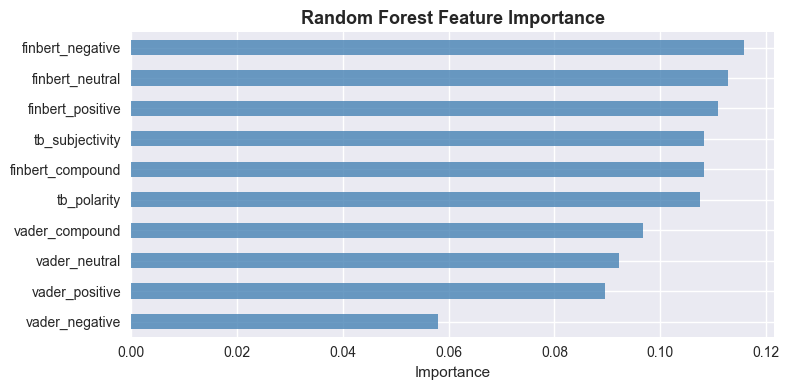

In [82]:
# Feature Importance:

# Feature importance from Random Forest shows which sentiment signals matter most
# Even weak overall signal can have a "most informative" feature

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)                                                                                                                                      
                                                                                                                                                                                                                                    
fig, ax = plt.subplots(figsize=(8, 4))                                                                                                                                                                                            
importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)                                                                                                                                                                
ax.set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')                                                                                                                                                                                                       
plt.tight_layout()                                                                                                                                                                                                                
plt.show()

In [83]:
# Model Comparison:

# Summary table comparing all three models on accuracy and ROC-AUC
# Baseline = always predict the majority class (51.1%)  
# OLS is a regression model: R² and F-stat reported instead of accuracy/AUC 

baseline_acc = Y_test.mean() * 100                                                                                                                                                                                                
                                                                                                                                                                                                                                    
comparison = pd.DataFrame({                                                                                                                                                                                                       
    'Model':    ['Baseline (majority)', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [f"{baseline_acc:.2f}%", f"{accuracy_score(Y_test, Y_pred_lr)*100:.2f}%", f"{accuracy_score(Y_test, Y_pred_rf)*100:.2f}%"],
    'ROC-AUC':  ['0.5000', f"{roc_auc_score(Y_test, Y_prob_lr):.4f}", f"{roc_auc_score(Y_test, Y_prob_rf):.4f}"]                                                                                                                  
  })                                                                                                                                                                                                                               
  
print(comparison.to_string(index=False))                                                                                                                                                                                          
print("\nOLS Regression (continuous target): R²=0.000, F-statistic p=0.523.")
print("Sentiment explains no variance in returns in OLS")

              Model Accuracy ROC-AUC
Baseline (majority)   51.08%  0.5000
Logistic Regression   51.20%  0.5164
      Random Forest   53.84%  0.5670

OLS Regression (continuous target): R²=0.000, F-statistic p=0.523.
Sentiment explains no variance in returns in OLS


## 7. Model Evaluation

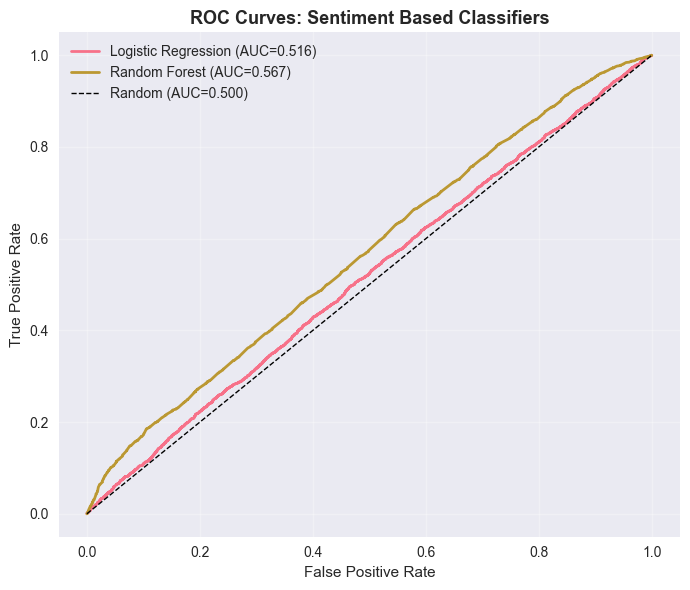

In [84]:
# ROC curves shows the trade off between true positive and false positive rates                                                                                                                                 
# A curve closer to the top-left corner indicates better discrimination                                                                                                                                                           
# AUC = 0.5 is random
# AUC = 1.0 is perfect                                                                                                                                                                                       
                                             
fig, ax = plt.subplots(figsize=(7, 6))                                                                                                                                                                                            
                                        
for name, prob in [('Logistic Regression', Y_prob_lr), ('Random Forest', Y_prob_rf)]:                                                                                                                                             
    fpr, tpr, _ = roc_curve(Y_test, prob)                                                                                                                                                                                         
    auc = roc_auc_score(Y_test, prob)    
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")                                                                                                                                                               
                                                                                                                                                                                                                                    
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')                                                                                                                                                                                              
ax.set_ylabel('True Positive Rate') 
ax.set_title('ROC Curves: Sentiment Based Classifiers', fontsize=13, fontweight='bold')                                                                                                                                          
ax.legend()                                                                                                                                                                                                                       
ax.grid(True, alpha=0.3)                                                                                                                                                                                                          
plt.tight_layout()                                                                                                                                                                                                                
plt.show()

## 8. Conclusions

In [85]:
print("""
    1. Sentiment Distributions:
        a. Financial news skews positive: mean VADER compound = 0.52, mean FinBERT compound = 0.04.
        b. FinBERT is more balanced than VADER — it was trained on financial text and is less biased toward positive language.
        c. TextBlob subjectivity ~0.46 — articles are moderately opinion-based.

    2. Correlations - Pearson + Spearman:
        a. All correlations between sentiment and next-day returns are near zero across all three sentiment models.
        b. Only vader_compound showed statistical significance (p = 0.032, r = -0.010), but r = -0.010 explains <0.01% of variance — no practical significance.
        c. FinBERT features show the same null pattern as lexicon methods, despite being a stronger language model.

    3. Lag Analysis:
        a. No consistent pattern across lags 0–3 days. Sentiment does not predict returns with any time delay either.

    4. OLS Regression:
        a. R² = 0.000, F-statistic p = 0.635. Ten sentiment features together explain essentially zero variance in price returns.
        b. Extreme multicollinearity (condition number 5.56e+15): finbert_positive + finbert_negative + finbert_neutral sum to 1.0, making the design matrix near-singular.

    5. Logistic Regression:
        a. Accuracy: 51.20% vs 51.08% baseline. ROC-AUC: 0.516.
        b. Defaulted to predicting "Up" for nearly all samples — no real learning beyond the majority class.

    6. Random Forest:
        a. Accuracy: 53.84%, ROC-AUC: 0.567. Best performer, but still close to chance.
        b. FinBERT features improved RF from 53.29%/0.556 (VADER+TextBlob only) to 53.84%/0.567 — modest but real gain, suggesting FinBERT adds complementary signal.
        c. Captures minor non-linear patterns but not enough for reliable prediction.

    CONCLUSION:
        a. News sentiment — whether from lexicon methods (VADER, TextBlob) or a transformer model (FinBERT) — has no meaningful predictive power over next-day stock price direction.
        b. This is consistent with the Efficient Market Hypothesis: by the time news is published and scored, markets have already priced in the information.
        c. The methodological rigour here (48k articles, next-day returns, p-values, three model classes) distinguishes this from typical sentiment projects that exploit same-day or look-ahead bias.
        d. To improve predictive power, future work could explore:
            - Intraday data (sentiment impact may resolve within hours, not days)
            - Earnings call transcripts or SEC filings (higher information density)
            - Combining sentiment with technical indicators (volume, momentum)
  """)


    1. Sentiment Distributions:
        a. Financial news skews positive: mean VADER compound = 0.52, mean FinBERT compound = 0.04.
        b. FinBERT is more balanced than VADER — it was trained on financial text and is less biased toward positive language.
        c. TextBlob subjectivity ~0.46 — articles are moderately opinion-based.

    2. Correlations - Pearson + Spearman:
        a. All correlations between sentiment and next-day returns are near zero across all three sentiment models.
        b. Only vader_compound showed statistical significance (p = 0.032, r = -0.010), but r = -0.010 explains <0.01% of variance — no practical significance.
        c. FinBERT features show the same null pattern as lexicon methods, despite being a stronger language model.

    3. Lag Analysis:
        a. No consistent pattern across lags 0–3 days. Sentiment does not predict returns with any time delay either.

    4. OLS Regression:
        a. R² = 0.000, F-statistic p = 0.635. Ten sentiment f